Step 1: Import Essential Libraries

In [1]:
import pandas as pd 

Step 2: Load Dataset

In [2]:
df = pd.read_csv('df_file.csv')
df.head()

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


Step03: Understand Data frame

In [3]:
df.shape

(2225, 2)

In [4]:
df['Label'].value_counts()

Label
1    511
4    510
0    417
2    401
3    386
Name: count, dtype: int64

In [5]:
df.isnull().sum()

Text     0
Label    0
dtype: int64

In [6]:
df.duplicated().sum()

98

Step 4: Data cleaning

In [7]:
df.drop_duplicates(inplace=True)
df['Label'].value_counts()

Label
1    505
4    503
0    403
3    369
2    347
Name: count, dtype: int64

Step 5: pre processing

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
import spacy

In [9]:
nlp = spacy.load("en_core_web_sm") 

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens) 

In [10]:
preprocess("Thor ate pizza")

'thor eat pizza'

In [11]:
df['Cleaned_Text'] = df['Text'].apply(preprocess)
df.head()

,Text,Label,Cleaned_Text
0,Budget to set scene for election\n \n Gordon B...,0,budget set scene election \n \n Gordon Brown ...
1,Army chiefs in regiments decision\n \n Militar...,0,army chief regiment decision \n \n military c...
2,Howard denies split over ID cards\n \n Michael...,0,Howard deny split ID card \n \n Michael Howar...
3,Observers to monitor UK election\n \n Minister...,0,observer monitor UK election \n \n Ministers ...
4,Kilroy names election seat target\n \n Ex-chat...,0,kilroy name election seat target \n \n ex cha...


Step 6: Modeling

In [12]:
from sklearn.model_selection import train_test_split

without text pre-processing

In [13]:
X = df['Text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer


Attempt 1 

In [30]:
from sklearn.neighbors import KNeighborsClassifier


In [31]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf', TfidfVectorizer()),    
     ('KNN', KNeighborsClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.96      0.82        79
           1       0.96      0.98      0.97       110
           2       0.92      0.87      0.89        62
           3       1.00      0.85      0.92        73
           4       0.99      0.84      0.91       102

    accuracy                           0.91       426
   macro avg       0.92      0.90      0.90       426
weighted avg       0.92      0.91      0.91       426



Attempt 2 

In [32]:
from sklearn.naive_bayes import MultinomialNB

In [33]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),    
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92        79
           1       0.93      1.00      0.96       110
           2       0.95      0.89      0.92        62
           3       1.00      0.79      0.89        73
           4       0.94      0.97      0.96       102

    accuracy                           0.93       426
   macro avg       0.94      0.92      0.93       426
weighted avg       0.94      0.93      0.93       426



Attempt 3 :

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),    
     ('Random Forest', RandomForestClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93        79
           1       0.94      1.00      0.97       110
           2       0.92      0.90      0.91        62
           3       0.99      0.90      0.94        73
           4       0.93      0.97      0.95       102

    accuracy                           0.94       426
   macro avg       0.95      0.94      0.94       426
weighted avg       0.94      0.94      0.94       426



use text pre-processing

In [37]:
X_cleaned = df['Cleaned_Text']
y_cleaned = df['Label']

X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

Attempt 4 :

In [39]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf', TfidfVectorizer()),    
     ('KNN', KNeighborsClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train_cleaned, y_train_cleaned)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test_cleaned)


#4. print the classfication report
print(classification_report(y_test_cleaned, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        79
           1       0.98      1.00      0.99       110
           2       0.85      0.94      0.89        62
           3       0.98      0.85      0.91        73
           4       0.95      0.89      0.92       102

    accuracy                           0.93       426
   macro avg       0.92      0.92      0.92       426
weighted avg       0.93      0.93      0.93       426



Attempt 5 :

In [40]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),    
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train_cleaned, y_train_cleaned)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test_cleaned)


#4. print the classfication report
print(classification_report(y_test_cleaned, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93        79
           1       0.98      1.00      0.99       110
           2       0.94      0.94      0.94        62
           3       1.00      0.86      0.93        73
           4       0.95      0.96      0.96       102

    accuracy                           0.95       426
   macro avg       0.95      0.95      0.95       426
weighted avg       0.95      0.95      0.95       426



Attempt 6:

In [38]:
#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),        
     ('Random Forest', RandomForestClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train_cleaned, y_train_cleaned)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test_cleaned)


#4. print the classfication report
print(classification_report(y_test_cleaned, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93        79
           1       0.97      0.99      0.98       110
           2       0.93      0.90      0.92        62
           3       0.99      0.90      0.94        73
           4       0.92      0.96      0.94       102

    accuracy                           0.95       426
   macro avg       0.95      0.94      0.94       426
weighted avg       0.95      0.95      0.95       426



output

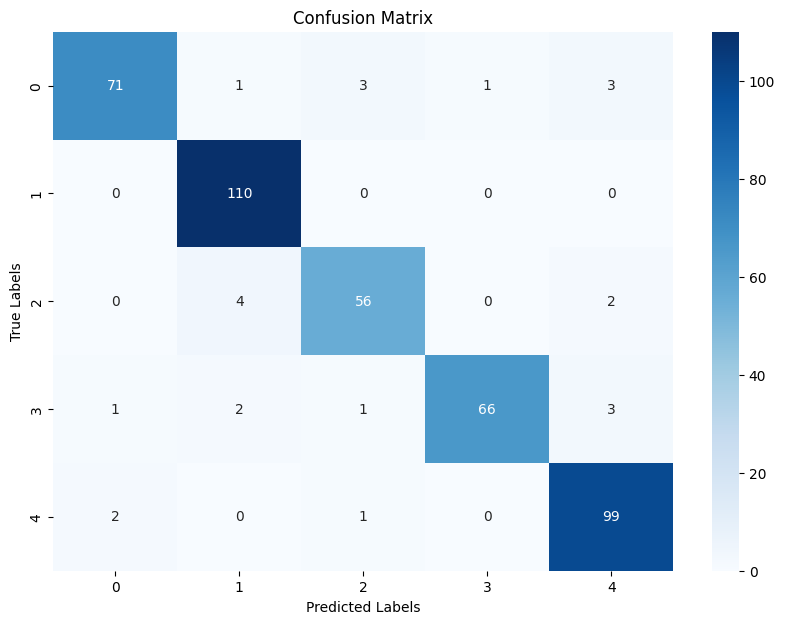

In [43]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test_cleaned, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_cleaned), yticklabels=set(y_cleaned))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

save all models

In [42]:
import joblib

# Save the K-Nearest Neighbors model
joblib.dump(Pipeline([
    ('vectorizer_tfidf', TfidfVectorizer()),    
    ('KNN', KNeighborsClassifier())         
]), 'knn_model.pkl')

# Save the Multinomial Naive Bayes model
joblib.dump(Pipeline([
    ('vectorizer_tfidf', TfidfVectorizer()),    
    ('Multi NB', MultinomialNB())         
]), 'multinomial_nb_model.pkl')

# Save the Random Forest model
joblib.dump(Pipeline([
    ('vectorizer_tfidf', TfidfVectorizer()),    
    ('Random Forest', RandomForestClassifier())         
]), 'random_forest_model.pkl')

['random_forest_model.pkl']